In [13]:
import xgboost as xgb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
from sklearn import tree
from sklearn.model_selection import RandomizedSearchCV

In [2]:
data = pd.read_csv('Titanic-Dataset.csv')

In [3]:
X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

numeric_features = ['Age', 'Fare']
X_train[numeric_features] = X_train[numeric_features].fillna(X_train[numeric_features].median())
X_test[numeric_features] = X_test[numeric_features].fillna(X_test[numeric_features].median())

sc = StandardScaler()
X_train[numeric_features] = sc.fit_transform(X_train[numeric_features])
X_test[numeric_features] = sc.transform(X_test[numeric_features])

categorical_features = ['Sex', 'Embarked']
X_train[categorical_features] = X_train[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])
X_test[categorical_features] = X_test[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])

X_train = pd.get_dummies(X_train, columns = categorical_features, dtype=int, drop_first = True)
X_test = pd.get_dummies(X_test, columns = categorical_features, dtype=int, drop_first = True)

X_train.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)
X_test.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)

In [4]:
#Q1) Install xgboost and train with default parameters on Titanic
kf = KFold(n_splits=5, shuffle=True, random_state=42)

model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores: {scores}')
print(f'Average Accuracy: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Cross-validation accuracy scores: [0.82894737 0.78289474 0.77483444 0.77483444 0.8013245 ]
Average Accuracy: 0.7926
Test set accuracy: 0.8358
Train set accuracy: 0.9577
Precision score is 0.8035714285714286
Recall score is 0.8035714285714286
F1 Score is 0.8035714285714286


In [23]:
#Q2) Add early stopping on the validation set
model = xgb.XGBClassifier(objective="binary:logistic", early_stopping_rounds = 20, random_state=42)

model.fit(X_train, y_train, eval_set = [(X_test, y_test)],verbose = False)

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Precision score is 0.8571428571428571
Recall score is 0.75
F1 Score is 0.8


In [9]:
'''
Q3) Compare XGBoost vs Random Forest — which performs better and why?

The precision scores are similar, however the recall scores differ RF achieved 0.73, XGB achieved 0.75. This effected the overall F1 score, RF = 0.76
and XGB is 0.8.
'''

'\nQ3) Compare XGBoost vs Random Forest — which performs better and why?\n\n'

In [19]:
#Q4) Tune with RandomizedSearchCV (not GridSearch — it is faster)

params = {'n_estimators' : [50, 100, 150, 200, 250],
          'max_depth' : [3, 5, 7, 9, 11],
          'learning_rate' : [0.1, 0.2, 0.01,0.4,0.3]
          }

model = xgb.XGBClassifier(objective="binary:logistic", random_state=42)

gs = RandomizedSearchCV(estimator = model, param_distributions = params, cv=10)


gs.fit(X_train, y_train)
test_accuracy = gs.score(X_test, y_test)
print(f"Test set accuracy: {test_accuracy:.4f}")


train_accuracy = gs.score(X_train, y_train)
print(f"Train set accuracy: {train_accuracy:.4f}")

y_pred = gs.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))
print(gs.best_params_, gs.best_score_)

Test set accuracy: 0.8209
Train set accuracy: 0.8692
Precision score is 0.8478260869565217
Recall score is 0.6964285714285714
F1 Score is 0.7647058823529411
{'n_estimators': 250, 'max_depth': 5, 'learning_rate': 0.01} 0.8177543859649121


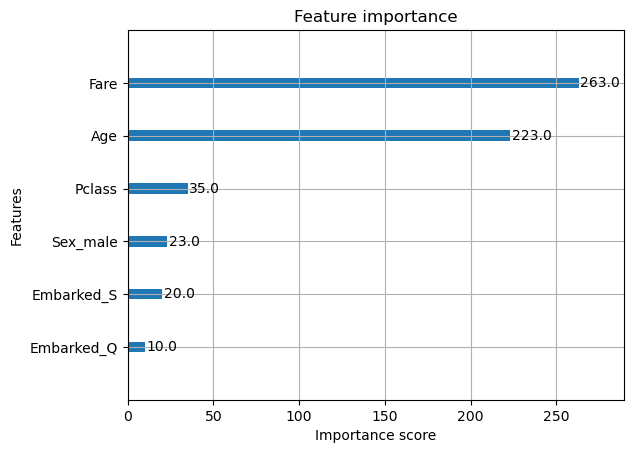

In [24]:
xgb.plot_importance(model)
plt.show()